In [14]:
import numpy as np
import matplotlib.pyplot as plt
import gizmo_analysis as gizmo
import matplotlib.colors as colors
import utilities as ut

from projection import Projection
from meta_data import *

import h5py

# Projection Tutorial

## Data

Data Citation: Garrison-Kimmel et al. 2017


In this tutorial, we use data from the FIRE-2 simulations which is publicly available (https://flathub.flatironinstitute.org/fire).

We use a snapshot at redshift z=0 from the core suite of the public data release. The galaxy m12b is approximately Milky Way mass with a halo mass $\sim 10^{12}$ $\text{M}_\odot$.



### Loading the Data
Set values to help with data loading

In [3]:
gal_name = 'm12b' # galaxy name for files
snap_idx = 600 # index of the snapshot to use (z=0)

In [15]:
def read_dataset(filepath, properties = 'all'):
    '''
    read hdf5 to dict
    '''
    header = {}
    data_dict = {}

        
    with h5py.File(filepath, "r") as f:
        for head in f.attrs.keys():
            header[head] = f.attrs[head]

        if properties == 'all':
            properties = f.keys()
        
        for property_name in properties:
            data_dict[property_name] = f[property_name][()]
            
    
    return data_dict, header

In [ ]:
data_dict, header = read_dataset('../../data/m12b_data.hdf5')



The data can be loaded using the h5py package.

To reduce computation time, we load only the particle species and properties required for this tutorial. In order to correctly assign the centre of the galaxy, we also require star particles and the expansion scale-factor when the star particle formed to correctly identify the centre of the host galaxy.

| Property | Description | Units |
| --- | --- | --- |
| position | Particle coordinates aligned with the galaxy principal <br> axes centred at the galaxies centre of mass | kpc |
| mass | Particle masses | $\text{M}_\odot$ |
| density | Particle density | $\text{M}_\odot/\text{kpc}^3$ |
| metallicity | Fraction of the mass that is in metals | - |
| volume | Particle volume | $\text{kpc}^3$|
| number.density.electrons  | Electron number density | $\text{cm}^{-3}$


In [17]:
data_dict

{'mass': array([ 7508.,  8432.,  9352., ...,  7408.,  8028., 16608.], dtype=float16),
 'metallicity': array([0.03442, 0.03058, 0.03174, ..., 0.03162, 0.03247, 0.03705],
       dtype=float16),
 'number.density.electrons': array([3.691e-03, 0.000e+00, 5.960e-08, ..., 1.460e-03, 2.899e-03,
        3.964e-05], dtype=float16),
 'position': array([[ -7.848,  -4.668,  -0.511],
        [ -7.79 ,  -4.656,  -0.562],
        [ -7.78 ,  -4.684,  -0.534],
        ...,
        [-10.81 ,   4.64 ,   1.204],
        [-10.766,   4.473,   1.264],
        [-10.79 ,   4.523,   1.349]], dtype=float16),
 'volume': array([2.580e-04, 1.271e-04, 8.065e-05, ..., 1.644e-03, 6.762e-04,
        1.394e-03], dtype=float16)}

In [18]:
header

{'data_citation': 'Garrison-Kimmel S., et al., 2019, Monthly Notices of the Royal Astronomical Society, 487, 1380',
 'data_type': 'particle',
 'gal_name': 'm12b',
 'n_particles': 2068554,
 'r_90': 10.944449936728121,
 'r_max': 20,
 'redshift': 4.440892098500626e-16,
 'snap_idx': 600,
 'species': 'gas'}

In [19]:
# Meta
resolution = 0.075 # kpc per pixel
box_size = 20 # kpc
meta = SimMeta.read_meta_from_keywords(box_size=box_size, resolution=resolution, distance_units='kpc', gal_name = gal_name)

To ensure an integer number of pixels, recalculating resolution to be consistent with rounded values.


## Projection Class

The Projection class can be used to create simple two dimensional projections from three dimensional particle data and meta data.

Particle data is passed as a dictionary which must contain the particle positions with the key 'position'.

To use the metallicity specific projection methods, the key 'metallicity' should be included and specify the metal mass fraction of each particle: $\frac{M_Z}{M_\text{total}}$.

### Required Parameters

**meta** : dict or SimulationMeta class
> the values to use to construct the pixels, the dictionary should contain the keys box_size, N_px, resolution
>> box_size : [float, float] The physical size for each dimension (Length_x, Length_y = box_size)<br>
N_px : [int, int] The number of pixels for each dimension (N_x, N_y = N_px)<br>
resolution : [float, float] The physical size of each pixel for each dimension (resolution_x, resolution_y = resolution)
    
(see SimulationMeta for more information)

**data_dict** : dict 
> dictionary containing particle data, must contain the following key(s)
>> position : ndarray shape(N,3) The three dimensional position of each particle in cartesian coordinates

> to use the metallicity_map and weighted_metallicity_map methods, the dictionary should also include the special key:
>> metallicity : a one dimensional array of the metal mass fraction of each particle

> 

See section [Aditional Parameters](#addtional-parameters) for the non-required parameters

In [20]:
proj = Projection(meta, data_dict)

Once initialised, Projection stores the data_dict without the positions in the data attribute; the positions are stored separately as the position attribute.

All data is reduced so that only values within the image boundaries are stored. Additional properties can be added using [add_particle_data](#adding-particle-data).



If you just want to know how to project data, skip to [Creating Projections](#division_ID).

In [21]:
proj.data, proj.position

({'mass': array([ 7508.,  8432.,  9352., ..., 11160.,  9328.,  8584.], dtype=float16),
  'metallicity': array([0.03442, 0.03058, 0.03174, ..., 0.0349 , 0.03452, 0.03256],
        dtype=float16),
  'number.density.electrons': array([3.691e-03, 0.000e+00, 5.960e-08, ..., 4.436e-03, 1.216e-02,
         1.351e-02], dtype=float16),
  'volume': array([2.580e-04, 1.271e-04, 8.065e-05, ..., 9.766e-04, 1.523e-03,
         1.893e-03], dtype=float16)},
 array([[-7.84765625, -4.66796875, -0.51123047],
        [-7.7890625 , -4.65625   , -0.56201172],
        [-7.78125   , -4.68359375, -0.53417969],
        ...,
        [-8.8671875 , -6.22265625,  1.07128906],
        [-8.8203125 , -6.2890625 ,  0.94189453],
        [-8.7421875 , -6.26171875,  0.96289062]]))

### Attributes
Projection stores the following attributes:

> [N_px, box_size, resolution](#n_px-box_size-resolution-)

>> are all inherited from meta

> [boundaries](#boundaries) : array, shape(2,2)
>> The leftmost and rightmost edges of the bins along each dimension, similar to the range argument of the np.histogram2d function. When flattened can be passed to the extent argument of plt.imshow.

> [bin_edges](#bin_edges): [array, array]
>> the pixel edges in each dimension (x_edges, y_edges = pixel_boundaries)

> total_pixels : int
>> the total number of pixels in the final image

> [x_bindices, y_bindices](#x_bindices-and-y_bindices)
>>  the indices of the pixels to which each particles position belongs along each dimension



#### N_px, box_size, resolution

Projection inherits from meta so the metadata is also stored as attributes.

In [22]:
print(f'resolution: {proj.resolution}')
print(f'N_px: {proj.N_px}')
print(f'box_size: {proj.box_size}')


resolution: [0.07518797 0.07518797]
N_px: [266 266]
box_size: [20 20]


#### boundaries

The boundaries of the image or a box of `self.box_size` centred at the galaxy centre passed to the constructor. The boundaries attribute is a 2x2 array of values so that x_bounds, y_bounds = boundaries and x_min, x_max = x_bounds

In [23]:
print(proj.boundaries)
print(proj.distance_units)

[[-10.  10.]
 [-10.  10.]]
kpc


#### bin_edges
The x and y values of the pixel edges or bins. The length for each dimension should be N_px[dim]+1.

In [24]:
print('x bins:', proj.bin_edges[0])

x bins: [-10.          -9.92481203  -9.84962406  -9.77443609  -9.69924812
  -9.62406015  -9.54887218  -9.47368421  -9.39849624  -9.32330827
  -9.2481203   -9.17293233  -9.09774436  -9.02255639  -8.94736842
  -8.87218045  -8.79699248  -8.72180451  -8.64661654  -8.57142857
  -8.4962406   -8.42105263  -8.34586466  -8.27067669  -8.19548872
  -8.12030075  -8.04511278  -7.96992481  -7.89473684  -7.81954887
  -7.7443609   -7.66917293  -7.59398496  -7.51879699  -7.44360902
  -7.36842105  -7.29323308  -7.21804511  -7.14285714  -7.06766917
  -6.9924812   -6.91729323  -6.84210526  -6.76691729  -6.69172932
  -6.61654135  -6.54135338  -6.46616541  -6.39097744  -6.31578947
  -6.2406015   -6.16541353  -6.09022556  -6.01503759  -5.93984962
  -5.86466165  -5.78947368  -5.71428571  -5.63909774  -5.56390977
  -5.4887218   -5.41353383  -5.33834586  -5.26315789  -5.18796992
  -5.11278195  -5.03759398  -4.96240602  -4.88721805  -4.81203008
  -4.73684211  -4.66165414  -4.58646617  -4.5112782   -4.43609023
  

In [17]:
print('y bins:', proj.bin_edges[1])

y bins: [-15.    -14.925 -14.85  -14.775 -14.7   -14.625 -14.55  -14.475 -14.4
 -14.325 -14.25  -14.175 -14.1   -14.025 -13.95  -13.875 -13.8   -13.725
 -13.65  -13.575 -13.5   -13.425 -13.35  -13.275 -13.2   -13.125 -13.05
 -12.975 -12.9   -12.825 -12.75  -12.675 -12.6   -12.525 -12.45  -12.375
 -12.3   -12.225 -12.15  -12.075 -12.    -11.925 -11.85  -11.775 -11.7
 -11.625 -11.55  -11.475 -11.4   -11.325 -11.25  -11.175 -11.1   -11.025
 -10.95  -10.875 -10.8   -10.725 -10.65  -10.575 -10.5   -10.425 -10.35
 -10.275 -10.2   -10.125 -10.05   -9.975  -9.9    -9.825  -9.75   -9.675
  -9.6    -9.525  -9.45   -9.375  -9.3    -9.225  -9.15   -9.075  -9.
  -8.925  -8.85   -8.775  -8.7    -8.625  -8.55   -8.475  -8.4    -8.325
  -8.25   -8.175  -8.1    -8.025  -7.95   -7.875  -7.8    -7.725  -7.65
  -7.575  -7.5    -7.425  -7.35   -7.275  -7.2    -7.125  -7.05   -6.975
  -6.9    -6.825  -6.75   -6.675  -6.6    -6.525  -6.45   -6.375  -6.3
  -6.225  -6.15   -6.075  -6.     -5.925  -5.85   -5.77

In [25]:
print('N_px:', proj.N_px)
print('length of x_bins:', proj.bin_edges[0].shape)
print('length of y_bins:', proj.bin_edges[1].shape)

N_px: [266 266]
length of x_bins: (267,)
length of y_bins: (267,)


#### x_bindices and y_bindices
The index of the pixel that the particle position falls into along each dimension. These are stored to avoid recomputing in the case of multiple projections with the same resolution but using different pixel values.


In [26]:
print(f'x position of the first 10 particles: {proj.position[:10, 0]}')
print(f'x idx of the pixel that their position falls in: {proj.x_bindices[:10]}')
print(f'left edge of each x pixel: {proj.bin_edges[0][proj.x_bindices[:10]]}')
print(f'right edge of each x pixel: {proj.bin_edges[0][proj.x_bindices[:10]+1]}')

x position of the first 10 particles: [-7.84765625 -7.7890625  -7.78125    -7.796875   -7.7734375  -7.77734375
 -7.79296875 -7.8125     -7.79296875 -7.83203125]
x idx of the pixel that their position falls in: [28 29 29 29 29 29 29 29 29 28]
left edge of each x pixel: [-7.89473684 -7.81954887 -7.81954887 -7.81954887 -7.81954887 -7.81954887
 -7.81954887 -7.81954887 -7.81954887 -7.89473684]
right edge of each x pixel: [-7.81954887 -7.7443609  -7.7443609  -7.7443609  -7.7443609  -7.7443609
 -7.7443609  -7.7443609  -7.7443609  -7.81954887]


### Constructing Coordinates of Pixel Centres

#### Finding the centres
The location of the centre of each pixel along each dimension can be found using the find_bin_centres method. The parameters are:
> [bin_edges](#bin_edges) : [array] or [array, array], optional*
>> the edges of the pixels in a single dimension or along each dimension <br> default is None, results in self.bin_edges as the value

> dim : int, optional*
>> The dimension of to use to find the bin centres in the case of multidimensional bin edges.

<div class="alert alert-block alert-danger">
<b>OPTIONAL ISN'T AS OPTIONAL AS YOU THINK</b>: Although both bin_edges and dim optional, an error will occur if multidimensional bin_edges are provided (or default used) and no value of dim is specified.
</div>


In [20]:
# default bin_edges with no specified dim results in an error
# proj.find_bin_centres()

<div class="alert alert-block alert-info">
<b>Defaults</b>: the default value of bin_edges results in using the bin_edges attribute. To use this, specify the dimension to find the centres along.
</div>

In [27]:
proj.find_bin_centres(dim=0) # the x coordinate of the pixel centre

array([-9.96240602, -9.88721805, -9.81203008, -9.73684211, -9.66165414,
       -9.58646617, -9.5112782 , -9.43609023, -9.36090226, -9.28571429,
       -9.21052632, -9.13533835, -9.06015038, -8.98496241, -8.90977444,
       -8.83458647, -8.7593985 , -8.68421053, -8.60902256, -8.53383459,
       -8.45864662, -8.38345865, -8.30827068, -8.23308271, -8.15789474,
       -8.08270677, -8.0075188 , -7.93233083, -7.85714286, -7.78195489,
       -7.70676692, -7.63157895, -7.55639098, -7.48120301, -7.40601504,
       -7.33082707, -7.2556391 , -7.18045113, -7.10526316, -7.03007519,
       -6.95488722, -6.87969925, -6.80451128, -6.72932331, -6.65413534,
       -6.57894737, -6.5037594 , -6.42857143, -6.35338346, -6.27819549,
       -6.20300752, -6.12781955, -6.05263158, -5.97744361, -5.90225564,
       -5.82706767, -5.7518797 , -5.67669173, -5.60150376, -5.52631579,
       -5.45112782, -5.37593985, -5.30075188, -5.22556391, -5.15037594,
       -5.07518797, -5.        , -4.92481203, -4.84962406, -4.77

In [22]:
proj.find_bin_centres(dim=1) # the y coordinate of the pixel centres

array([-14.9625, -14.8875, -14.8125, -14.7375, -14.6625, -14.5875,
       -14.5125, -14.4375, -14.3625, -14.2875, -14.2125, -14.1375,
       -14.0625, -13.9875, -13.9125, -13.8375, -13.7625, -13.6875,
       -13.6125, -13.5375, -13.4625, -13.3875, -13.3125, -13.2375,
       -13.1625, -13.0875, -13.0125, -12.9375, -12.8625, -12.7875,
       -12.7125, -12.6375, -12.5625, -12.4875, -12.4125, -12.3375,
       -12.2625, -12.1875, -12.1125, -12.0375, -11.9625, -11.8875,
       -11.8125, -11.7375, -11.6625, -11.5875, -11.5125, -11.4375,
       -11.3625, -11.2875, -11.2125, -11.1375, -11.0625, -10.9875,
       -10.9125, -10.8375, -10.7625, -10.6875, -10.6125, -10.5375,
       -10.4625, -10.3875, -10.3125, -10.2375, -10.1625, -10.0875,
       -10.0125,  -9.9375,  -9.8625,  -9.7875,  -9.7125,  -9.6375,
        -9.5625,  -9.4875,  -9.4125,  -9.3375,  -9.2625,  -9.1875,
        -9.1125,  -9.0375,  -8.9625,  -8.8875,  -8.8125,  -8.7375,
        -8.6625,  -8.5875,  -8.5125,  -8.4375,  -8.3625,  -8.2

#### Coordinates of each pixel
The above gives us all of the unique x and y values for each pixel centre, but not the location of each pixel centre. We may want a two dimensional array of shape N_px which contains the coordinate of the pixel centre along both dimensions. We can construct this manually from the bin centres as,

<code>np.meshgrid(proj.find_bin_centres(dim=0), proj.find_bin_centres(dim=1)) </code>

or simply using the find_pixel_centre_coord_grid method:

In [17]:
x_pixel_centres, y_pixel_centres = proj.find_pixel_centre_coord_grid()

print(x_pixel_centres)
print(y_pixel_centres)

[[-14.9625 -14.8875 -14.8125 ...  14.8125  14.8875  14.9625]
 [-14.9625 -14.8875 -14.8125 ...  14.8125  14.8875  14.9625]
 [-14.9625 -14.8875 -14.8125 ...  14.8125  14.8875  14.9625]
 ...
 [-14.9625 -14.8875 -14.8125 ...  14.8125  14.8875  14.9625]
 [-14.9625 -14.8875 -14.8125 ...  14.8125  14.8875  14.9625]
 [-14.9625 -14.8875 -14.8125 ...  14.8125  14.8875  14.9625]]
[[-14.9625 -14.9625 -14.9625 ... -14.9625 -14.9625 -14.9625]
 [-14.8875 -14.8875 -14.8875 ... -14.8875 -14.8875 -14.8875]
 [-14.8125 -14.8125 -14.8125 ... -14.8125 -14.8125 -14.8125]
 ...
 [ 14.8125  14.8125  14.8125 ...  14.8125  14.8125  14.8125]
 [ 14.8875  14.8875  14.8875 ...  14.8875  14.8875  14.8875]
 [ 14.9625  14.9625  14.9625 ...  14.9625  14.9625  14.9625]]


### Creating Projections

Project three dimensional particle data and create a two dimensional image.
#### Project

A projection of one variable is the sum of the value of that variable for each particle which falls within that pixel. For a pixel with index (i,j) with edges located at $x_i, x_{i+1}$ and $y_j, y_{j+1}$, the value of the pixel $V_{ij}$,

$$V_{ij} = \sum_{n} v_n,$$

where $v_n$ is the particle values and the sum runs over the particles whose coordinates $(x_n, y_n)$ are inside the pixel boundaries, i.e. $x_i < x_n < x_{i+1}$ _and_  $y_i < y_n < y_{i+1}$.

This can easily be done for any variable in the data_dict by passing the corresponding key to the project method:

In [28]:
M = proj.project('mass') # mass is in M_sun
print(M)

[[ 54452.  61404.  50980. ...  32732.   8776.  30240.]
 [ 75104. 101056.  70604. ...  28160.  29968.  18856.]
 [126212.  65116.  98108. ...  31464.  16616.   8728.]
 ...
 [137424.  96396.  53260. ...  44176.  76812.      0.]
 [120656.  80716.  62236. ...  48280.  53908.  30848.]
 [ 61744.  59960.   7408. ...  27532.  18920.      0.]]


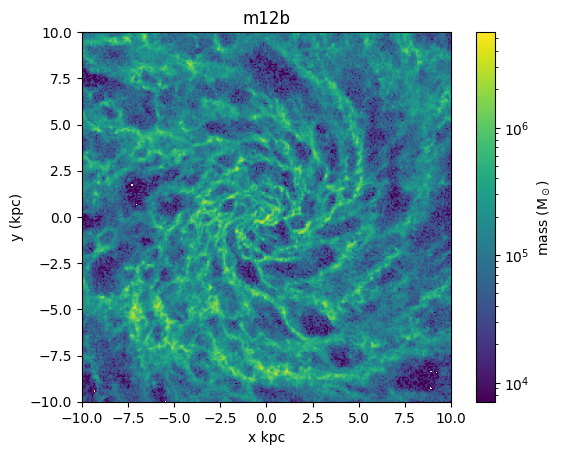

In [29]:
plt.imshow(M, norm=colors.LogNorm(), extent=proj.boundaries.flatten())
plt.ylabel(f'y ({proj.distance_units})') # use the stored distance units
plt.xlabel(f'x {proj.distance_units}') # use the stored distance units
plt.title(proj.gal_name) # use the stored galaxy name for the title
plt.colorbar(label=r'mass (M$_\odot$)')

##### Per Unit Area
To compute a projected quantity per unit area, set per_unit_area to True. For example, column density is a commonly used astrophysical variable. Column density is the mass per unit area,

$$\Sigma = \frac{M}{A},$$

which can be calculated using,

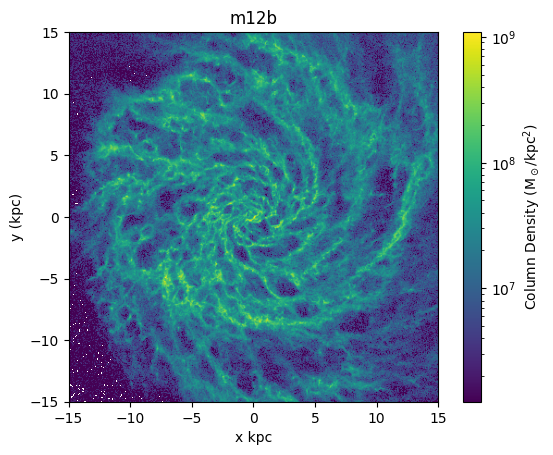

In [20]:
column_density = proj.project('mass', per_unit_area=True)

plt.imshow(column_density, norm=colors.LogNorm(), extent=proj.boundaries.flatten())
plt.ylabel(f'y ({proj.distance_units})') # use the stored distance units
plt.xlabel(f'x {proj.distance_units}') # use the stored distance units
plt.title(proj.gal_name) # use the stored galaxy name for the title
plt.colorbar(label=r'Column Density (M$_\odot$/{dist_unit}$^2$)'.format(dist_unit = proj.distance_units))

#### Weighted Projection

Weighted projections can be calculated using the weighted_project method. A weighted projection is the weighted sum of the value of that variable for each particle which falls into that pixel. For a pixel with index (i,j) with edges located at $x_i, x_{i+1}$ and $y_j, y_{j+1}$, the projection of $v$ weighted by $w$ is,

$$V_{ij} = \frac{\sum_{n} v_n w_n}{\sum_{n} w_n}$$

where $v_n$ is the particle variable values, $w_n$ is particle weight value and the sum runs over the particles whose coordinates $(x_n, y_n)$ are inside the pixel boundaries, i.e. $x_i < x_n < x_{i+1}$ _and_  $y_i < y_n < y_{i+1}$.

For example, the metallicity map is,
$$Z_{ij} = \frac{\sum_{n} Z_n m_n}{\sum_{n} m_n},$$

where $Z_n$ is the metal mass fraction of each particle within the pixel boundary and $m_n$ is the particle mass.

To implement this using the Projection class, we first define a weights function which takes the data_dict as its only argument. The available keys are those which are included in proj.data. This is a simple example, but it allows for the computation of more complex weighted projections.


In [21]:
def mass_weights(data_dict):
    return data_dict['mass']

In [22]:
Z_map = proj.weighted_project('metallicity', mass_weights)

/Users/tree/Documents/Uni/Masters_Degree/research_porject/python_functions/projection/projection.py:369: RuntimeWarning: invalid value encountered in divide
  return self.project_values(vals * weights)/ self.project_values(weights)


The value of each pixel in the metallicity map is the total fraction of the pixel mass which is in metals (everything that is not hydrogren or helium). This is frequently quoted in solar metallicity units:

$$Z = \log_{10}\frac{\text{metal massfraction}}{\text{solar metal massfraction}} $$


The solar metallicity value is 0.0134 (Asplund et al. 2009)

In [23]:
Z_map = np.log10(Z_map/0.0134)

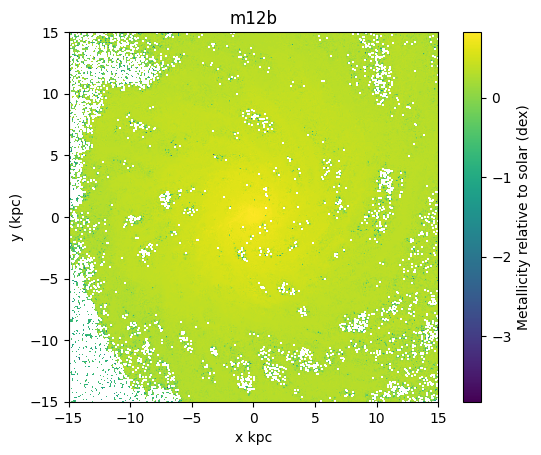

In [24]:
plt.imshow(Z_map, extent=proj.boundaries.flatten())
plt.ylabel(f'y ({proj.distance_units})') # use the stored distance units
plt.xlabel(f'x {proj.distance_units}') # use the stored distance units
plt.title(proj.gal_name) # use the stored galaxy name for the title
plt.colorbar(label=r'Metallicity relative to solar (dex)')

#### Metallicity Maps
For convenience, the metallicity map has a special method. If the data dictionary contains the particle metal mass fractions under the key 'metallicity', and the particle masses as 'mass', the metallicity map can also be calculated using an inbuilt method, metallicity_map(). The units are dex relative to solar.


/Users/tree/Documents/Uni/Masters_Degree/research_porject/python_functions/projection/projection.py:369: RuntimeWarning: invalid value encountered in divide
  return self.project_values(vals * weights)/ self.project_values(weights)


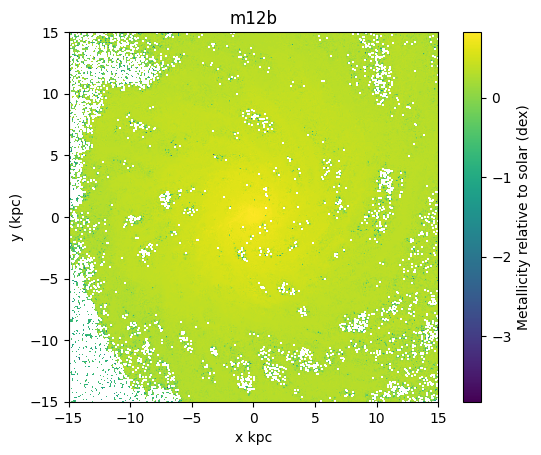

In [30]:
Z_map = proj.metallicity_map()

plt.imshow(Z_map, extent=proj.boundaries.flatten())
plt.ylabel(f'y ({proj.distance_units})') # use the stored distance units
plt.xlabel(f'x {proj.distance_units}') # use the stored distance units
plt.title(proj.gal_name) # use the stored galaxy name for the title
plt.colorbar(label=r'Metallicity relative to solar (dex)')

##### Weighted Metallicity Map

On the occasion where additional weighting is required, use the weighted metallicity map method. The value of each pixel is assigned according to,

$$Z_{ij} = \frac{\sum_{n} Z_n m_n w_n}{\sum_{n} m_n \sum_{n} w_n},$$

where, as before, $Z_n$ is the metal mass fraction of each particle within the pixel boundary, $m_n$ is the particle mass
and $w_n$ is the weight for each particle. The sum, as ever, runs over the particles whose coordinates $(x_n, y_n)$ are inside the pixel boundaries, i.e. $x_i < x_n < x_{i+1}$ _and_  $y_j < y_n < y_{j+1}$.

eg. weight by:
$$L \propto \int_V n_e^2 dV$$

In [31]:
def luminosity_weights_func(data_dict):
    '''
    see markdown cell above
    
    '''

    n_e = data_dict['number.density.electrons'] # in cm^-3
    
    V = data_dict['volume'] #in kpc^3

    return (n_e**2) * V # this isn't meaningful as a value only as a weight

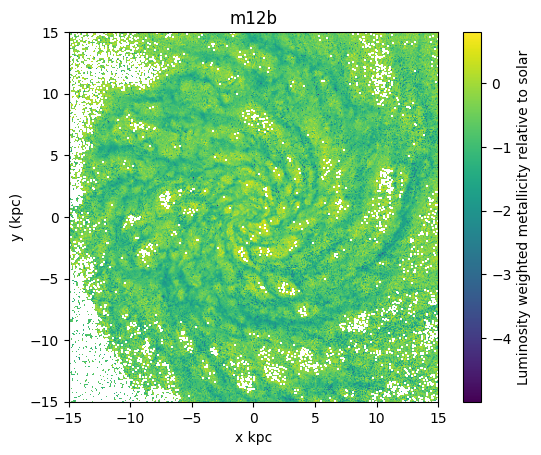

In [32]:
luminosity_weighted_Z = proj.weighted_metallicity_map(luminosity_weights_func)


plt.imshow(luminosity_weighted_Z, extent=proj.boundaries.flatten())
plt.ylabel(f'y ({proj.distance_units})') # use the stored distance units
plt.xlabel(f'x {proj.distance_units}') # use the stored distance units
plt.title(proj.gal_name) # use the stored galaxy name for the title
plt.colorbar(label=r'Luminosity weighted metallicity relative to solar')

### Other Useful Functionality

#### Adding Particle Data

We can add additional data to the data_dict after initialisation using the method add_particle_data which takes a single parameter, a dictionary of particle data to add.

The keys should be a descriptor for the variable and the corresponding dictionary value should be a list with the same length as the initial data passed to the constructor.

To demonstrate, let's store the particle masses as a variable and remove them from the data_dict:

In [38]:
masses = data_dict['mass']

data_dict.pop('mass')

array([7067.277, 7067.277, 7067.277, ..., 7067.277, 7067.277, 7067.277],
      dtype=float32)

Then create an instance of Projection using the new dictionary (and the same meta). The data attribute should no longer contain 'mass' as a key:

In [39]:
proj = Projection(meta, data_dict)

print(proj.data.keys()) # no mass

dict_keys(['density', 'metallicity', 'volume', 'number.density.electrons'])


We can then add it back in using:

In [40]:
proj.add_particle_data({'mass': masses})

{'density': array([2.9111954e+07, 6.6398192e+07, 1.1602811e+08, ..., 4.5059780e+06,
        1.1868119e+07, 1.1909192e+07], dtype=float32),
 'metallicity': array([0.03443033, 0.03057529, 0.03173599, ..., 0.03161867, 0.03247442,
        0.03705803], dtype=float32),
 'volume': array([2.5793817e-04, 1.2703273e-04, 8.0627164e-05, ..., 1.6441704e-03,
        6.7629630e-04, 1.3941234e-03], dtype=float32),
 'number.density.electrons': array([3.69029437e-03, 1.11402575e-08, 6.68348593e-08, ...,
        1.46031544e-03, 2.89858778e-03, 3.96229521e-05]),
 'mass': array([ 7509.0845,  8434.744 ,  9355.018 , ...,  7408.5957,  8026.3647,
        16602.883 ], dtype=float32)}

In [41]:
data_dict

{'position': array([[ 1894.56142926, -1445.2330866 ,  4401.88053958],
        [ 1894.07775844, -1465.86189369,  4388.56064727],
        [ 1900.01210021, -1453.61839088,  4385.11092383],
        ...,
        [-2207.69410182,  -116.69194475,  -620.73078027],
        [-2205.86131446,  -111.37924321,  -622.96396757],
        [-2211.69550669,  -118.03537878,  -621.00627445]]),
 'density': array([ 0.34891936,  0.58965653,  0.6418527 , ..., 67.88182   ,
        60.887413  , 74.81389   ], dtype=float32),
 'metallicity': array([2.0059886e-06, 2.0013933e-06, 2.0006025e-06, ..., 2.1098126e-06,
        8.0666523e-06, 2.2200084e-06], dtype=float32),
 'volume': array([20254.758  , 11985.413  , 11010.746  , ...,   104.11148,
          116.07123,    94.46477], dtype=float32),
 'number.density.electrons': array([1.23565218e-08, 2.08817957e-08, 2.27301458e-08, ...,
        2.39875834e-06, 2.15221628e-06, 2.64333778e-06])}

In [43]:
data_dict['mass'] = masses

#### Additional Parameters

Projection can take additional parameters which allows for additional functionality. These are,
> [rotation_angles](#rotation) : [float, float, float]
>> rotation angles about x-axis, y-axis, z-axis (radians)

> [centre](#projections-using-particles-where-coords-dont-align-with-galaxy-centre) : [float, float, float]
>>the x, y, z coordinate of the centre of the galaxy in the coordinate system of the particle data (default = [0,0,0])

> z_bound : float
>> the maximum distance along the projection axis that particles are included (default=infinity)


##### Rotation

We can also use Projection to rotate the coordinates and project along a different axis than the one the data is aligned with. Rotation is done through the constructor, as the bindices depend on the new coordinates.

(This code uses the get_coordinates_rotated from utilities_awetzel)

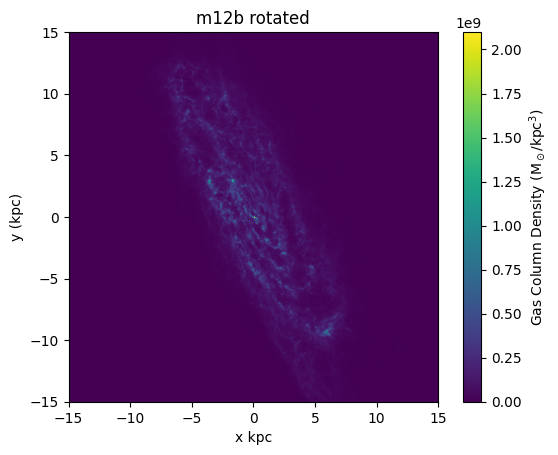

In [44]:
rotation_angles=[np.pi/3,np.pi/3,0]

proj = Projection(meta, data_dict, rotation_angles=[np.pi/3,np.pi/3,0]) # create rotated projection


plt.imshow(proj.project('mass', per_unit_area=True), extent=proj.boundaries.flatten())
plt.title(f'{proj.gal_name} rotated') # use the stored galaxy name for the title
plt.ylabel(f'y ({proj.distance_units})') # use the stored distance units
plt.xlabel(f'x {proj.distance_units}') # use the stored distance units
plt.colorbar(label=r'Gas Column Density (M$_\odot$/{dist_units}$^3$)'.format(dist_units=proj.distance_units))

<b> Edge on projection </b>

Rotate coordinates to look along the x-z plane:

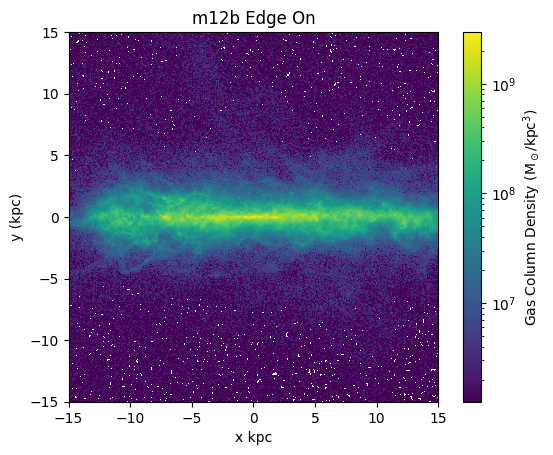

In [45]:

rotation_angles=[0,np.pi/2, 0]
proj = Projection(meta, data_dict, rotation_angles=rotation_angles)

plt.imshow(proj.project('mass', per_unit_area=True), extent=proj.boundaries.flatten(), norm=colors.LogNorm())
plt.title(f'{proj.gal_name} Edge On')
plt.ylabel(f'y ({proj.distance_units})') # use the stored distance units
plt.xlabel(f'x {proj.distance_units}') # use the stored distance units
plt.colorbar(label=r'Gas Column Density (M$_\odot$/{dist_units}$^3$)'.format(dist_units=proj.distance_units))

#### Projections Using Particles Where Coordinates Don't Align with Galaxy Centre

Projection can also be used to recentre the galaxy to an imput centre value.

We begin by artifically shifting the coordinates to be centred at [10,0,0].

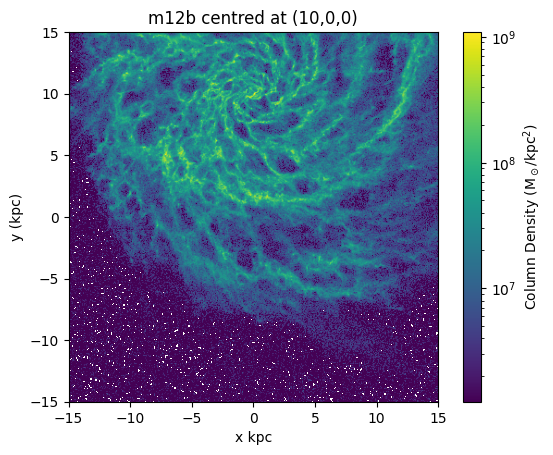

In [46]:
data_dict['position'][:,0] = data_dict['position'][:,0] - 10

proj = Projection(meta, data_dict)

column_density = proj.project('mass', per_unit_area=True)

plt.imshow(column_density, norm=colors.LogNorm(), extent=proj.boundaries.flatten())
plt.ylabel(f'y ({proj.distance_units})') # use the stored distance units
plt.xlabel(f'x {proj.distance_units}') # use the stored distance units
plt.title(f'{proj.gal_name} centred at (10,0,0)') # use the stored galaxy name for the title
plt.colorbar(label=r'Column Density (M$_\odot$/{dist_unit}$^2$)'.format(dist_unit = proj.distance_units))

Then, by passing the new centre value to the constructor, we can reproduce the correctly centred projections as before:

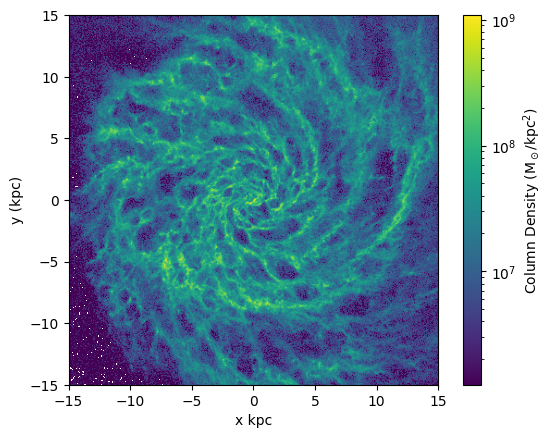

In [48]:
proj = Projection(meta, data_dict, centre=[10,0,0])

column_density = proj.project('mass', per_unit_area=True)

plt.imshow(column_density, norm=colors.LogNorm(), extent=proj.boundaries.flatten())
plt.ylabel(f'y ({proj.distance_units})') # use the stored distance units
plt.xlabel(f'x {proj.distance_units}') # use the stored distance units

plt.colorbar(label=r'Column Density (M$_\odot$/{dist_unit}$^2$)'.format(dist_unit = proj.distance_units))